<a href="https://colab.research.google.com/github/garrick-watkins/MIS-433/blob/main/Copy_of_assignment_IMDB_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment - Analyzing the IMDB Top 1000 Movies

In the next few assignments, you will be working with this data set of IMDB top 1000 movies.

Source: https://www.kaggle.com/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows

In [1]:
import pandas as pd
import numpy as np

In [2]:
# Read the data file "imdb_top_1000.csv" to a dataframe named "imdb"
imdb = pd.read_csv('https://raw.githubusercontent.com/jiexunli-wwu/mis433/refs/heads/main/data/imdb_top_1000.csv', header=0)
imdb.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [3]:
# Describe the dataframe using the info() method.
imdb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


In [4]:
# List all the column names:
imdb.columns

Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='object')

## Part 1: Data Manipulation

Redo the following to clean the data.

In [6]:
# Count the number of movies in each "Released_Year"?
# Hint: value_counts()
year_counts = imdb['Released_Year'].value_counts()
year_counts

,count
Released_Year,
2014,32
2004,31
2009,29
2013,28
2016,28
...,...
1920,1
1930,1
1922,1


In [7]:
# In this dataset, there is a movie with an error in "Released_Year".
# Hint: Released_Year should be a 4-digit integer but this movie's is not.
# Find this movie.
error_movie = imdb[~imdb['Released_Year'].str.isdigit()]
error_movie

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
966,https://m.media-amazon.com/images/M/MV5BNjEzYj...,Apollo 13,PG,U,140 min,"Adventure, Drama, History",7.6,NASA must devise a strategy to return Apollo 1...,77.0,Ron Howard,Tom Hanks,Bill Paxton,Kevin Bacon,Gary Sinise,269197,"173,837,933"


In [8]:
# Correct the values for the corresponding columns ("Release_Year" and "Certificate").
# You may want to look up this movie on www.imdb.com.
# Hint: You can set value for a particular set by: df.loc[row_name, column_name] = new_value
error = imdb[~imdb['Released_Year'].str.isdigit()].index[0]
imdb.loc[error, 'Released_Year'] = '1995'
imdb.loc[error, 'Certificate'] = 'PG'
imdb.loc[[error]]

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
966,https://m.media-amazon.com/images/M/MV5BNjEzYj...,Apollo 13,1995,PG,140 min,"Adventure, Drama, History",7.6,NASA must devise a strategy to return Apollo 1...,77.0,Ron Howard,Tom Hanks,Bill Paxton,Kevin Bacon,Gary Sinise,269197,"173,837,933"


In [9]:
# Change the data type of "Released_Year" to int
imdb['Released_Year'] = imdb['Released_Year'].astype(int)

In [10]:
# Select all movies released after (>=) 2010 and with IMDB_Rating>=8.5
# Show their title, released year, Certificate, and gross.
# Sort them in descending order of "Gross"
top_recent_movies = imdb[(imdb['Released_Year'] >= 2010) & (imdb['IMDB_Rating'] >= 8.5)]
result = top_recent_movies[['Series_Title', 'Released_Year', 'Certificate', 'Gross']]
final = result.sort_values(by='Gross', ascending=False)
final

,Series_Title,Released_Year,Certificate,Gross
19,Gisaengchung,2019,A,"53,367,844"
33,Joker,2019,A,"335,451,311"
8,Inception,2010,UA,"292,576,195"
21,Interstellar,2014,UA,"188,020,017"
35,The Intouchables,2011,UA,"13,182,281"
34,Whiplash,2014,A,"13,092,000"
18,Hamilton,2020,PG-13,NaN
20,Soorarai Pottru,2020,U,NaN


In [ ]:
# Does the sorting result looks right to you? What's the problem?
# 2 of the results do not contain gross

In [11]:
# Resolve this problem of "Gross" and convert its data type to float
# Hint: You may find this webpage useful:
# https://stackoverflow.com/questions/28986489/how-to-replace-text-in-a-column-of-a-pandas-dataframe
imdb['Gross'] = imdb['Gross'].str.replace(',', '').astype(float)

,Series_Title,Gross
0,The Shawshank Redemption,28341469.0
1,The Godfather,134966411.0
2,The Dark Knight,534858444.0
3,The Godfather: Part II,57300000.0
4,12 Angry Men,4360000.0


In [12]:
# Next, redo the sorting on Gross

# Select all movies released after (>=) 2010 and with IMDB_Rating>=8.5
# Show their title, released year, Certificate, and gross.
# Sort them in descending order of "Gross"
top_recent_movies = imdb[(imdb['Released_Year'] >= 2010) & (imdb['IMDB_Rating'] >= 8.5)]
result = top_recent_movies[['Series_Title', 'Released_Year', 'Certificate', 'Gross']]
final = result.sort_values(by='Gross', ascending=False)
final

,Series_Title,Released_Year,Certificate,Gross
33,Joker,2019,A,335451311.0
8,Inception,2010,UA,292576195.0
21,Interstellar,2014,UA,188020017.0
19,Gisaengchung,2019,A,53367844.0
35,The Intouchables,2011,UA,13182281.0
34,Whiplash,2014,A,13092000.0
18,Hamilton,2020,PG-13,NaN
20,Soorarai Pottru,2020,U,NaN


In [ ]:
# Add a new column "Runtime_min" by removing the substring ' min" in "Runtime"
# Set its data type as int
# Hint: https://stackoverflow.com/questions/36505847/substring-of-an-entire-column-in-pandas-dataframe


In [13]:
# Add a new column "Age_Year" by expression: [current year] - Released_Year
imdb['Runtime_min'] = imdb['Runtime'].str[:-4]
imdb['Runtime_min'] = imdb['Runtime_min'].astype(int)
imdb[['Series_Title', 'Runtime', 'Runtime_min']].head()

,Series_Title,Runtime,Runtime_min
0,The Shawshank Redemption,142 min,142
1,The Godfather,175 min,175
2,The Dark Knight,152 min,152
3,The Godfather: Part II,202 min,202
4,12 Angry Men,96 min,96


In [14]:
# Add a new column "Decade" with values as 1980, 1990, 2000, 2010, 2020, etc.
imdb['Decade'] = (imdb['Released_Year'] // 10) * 10
imdb[['Series_Title', 'Released_Year', 'Decade']].head()

,Series_Title,Released_Year,Decade
0,The Shawshank Redemption,1994,1990
1,The Godfather,1972,1970
2,The Dark Knight,2008,2000
3,The Godfather: Part II,1974,1970
4,12 Angry Men,1957,1950


## Part 2: Data Summarization

Done!

## Part 3: Data Visualization

Finish Parts 1 and 2 (data manipulation and summarization) before you work through this section.

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

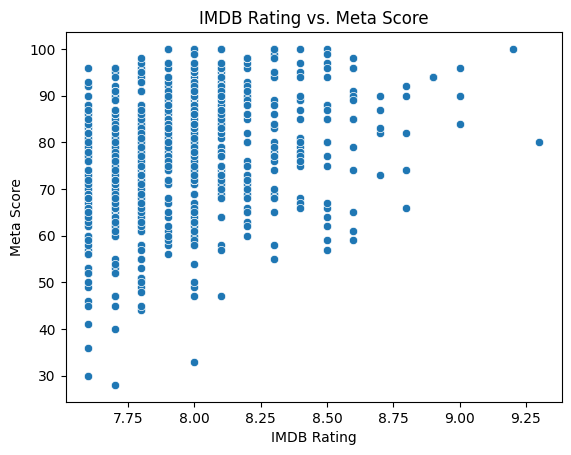

In [16]:
# Create a scatterplot of the two scores, "IMDB_Rating" and "Meta_score".
# In a sentence or two, describe what this pair of scores suggests about the movies.
# Create a scatterplot of the two scores, "IMDB_Rating" and "Meta_score"
sns.scatterplot(data=imdb, x='IMDB_Rating', y='Meta_score')
plt.title("IMDB Rating vs. Meta Score")
plt.xlabel("IMDB Rating")
plt.ylabel("Meta Score")
plt.show()
# here we see that there is a slight positive correlation between IMDB and Meta.
# this means that as IMDB increases so does meta.

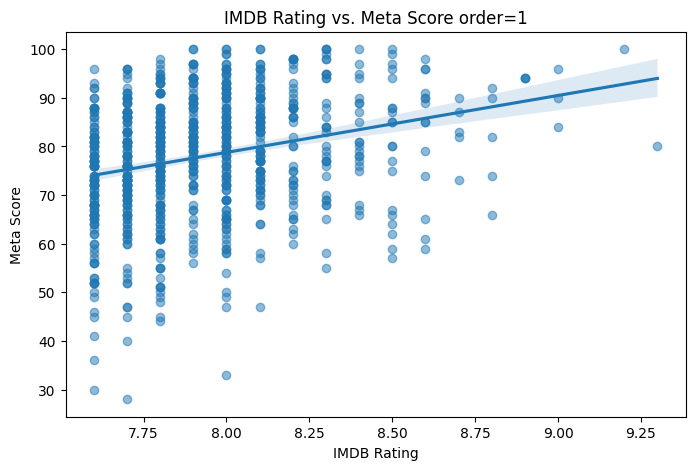

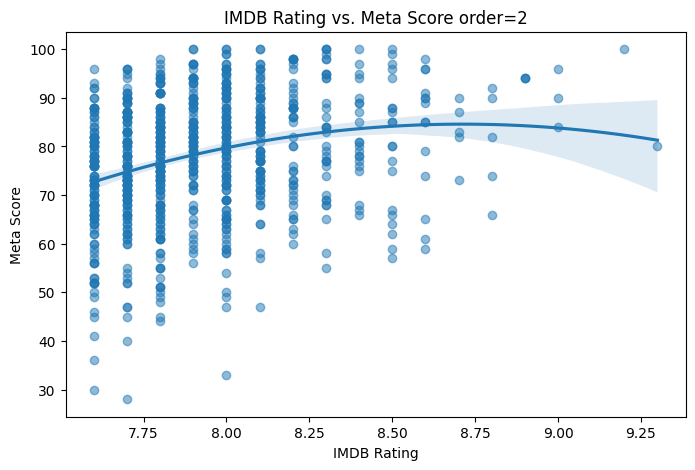

In [18]:
# Fit a trendline to show the relationship between the two scores.
# Hint: sns.regplot()
# Try a few values of the `order` argument (polynomial degree) for the trendline.
plt.figure(figsize=(8, 5))
sns.regplot(data=imdb, x='IMDB_Rating', y='Meta_score', order=1, scatter_kws={'alpha': 0.5})
plt.title("IMDB Rating vs. Meta Score order=1")
plt.xlabel("IMDB Rating")
plt.ylabel("Meta Score")
plt.show()

plt.figure(figsize=(8, 5))
sns.regplot(data=imdb, x='IMDB_Rating', y='Meta_score', order=2, scatter_kws={'alpha': 0.5})
plt.title("IMDB Rating vs. Meta Score order=2")
plt.xlabel("IMDB Rating")
plt.ylabel("Meta Score")
plt.show()

In [28]:
# Do any data points in the scatterplot surprise you?
# Try to identify a few such movies.
High_Meta_Low_IMDB = imdb[(imdb['IMDB_Rating']<7.75) & (imdb['Meta_score']>70)].sort_values(by='Meta_score', ascending=False).head(5)
High_Meta_Low_IMDB[['Series_Title', 'IMDB_Rating', 'Meta_score']]

#Low_Meta_High_IMDB = imdb[(imdb['IMDB_Rating']>9) & (imdb['Meta_score']<90)].sort_values(by='Meta_score', ascending=False).head(5)
#Low_Meta_High_IMDB[['Series_Title', 'IMDB_Rating', 'Meta_score']]

#The movie Roma Seems to have a very high Meta score with a relatively low IMDB score. Additionally the Shaw Shank Redemption is rated very high on IMDB but just good on Meta.

,Series_Title,IMDB_Rating,Meta_score
720,Roma,7.7,96.0
745,Gravity,7.7,96.0
875,Fantasia,7.7,96.0
994,A Hard Day's Night,7.6,96.0
748,The Social Network,7.7,95.0


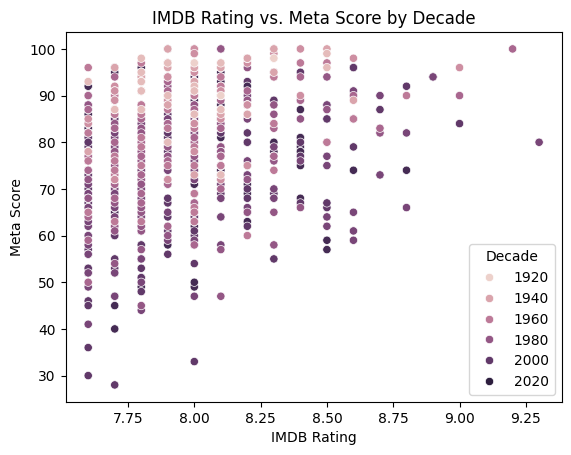

In [32]:
# In the scatterplot, use color to distinguish movies from different decades.
sns.scatterplot(
    data=imdb,
    x='IMDB_Rating',
    y='Meta_score',
    hue='Decade'
)

plt.title("IMDB Rating vs. Meta Score by Decade")
plt.xlabel("IMDB Rating")
plt.ylabel("Meta Score")

plt.legend(title='Decade')

plt.show()

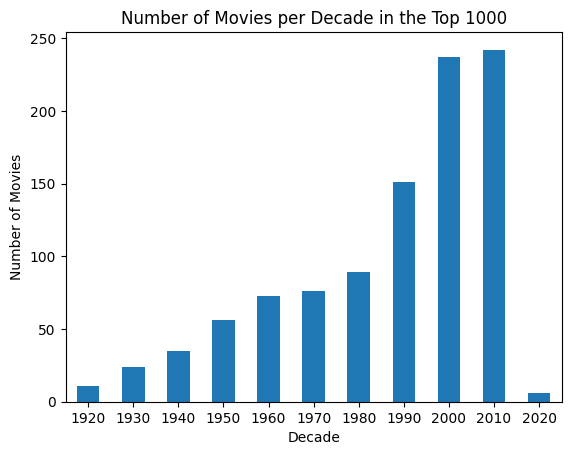

In [33]:
# Create a chart that shows how many movies fall in each decade.
decade_counts = imdb['Decade'].value_counts().sort_index()
decade_counts.plot(kind='bar')
plt.title("Number of Movies per Decade in the Top 1000")
plt.xlabel("Decade")
plt.ylabel("Number of Movies")
plt.xticks(rotation=0)
plt.show()

<Axes: ylabel='count'>

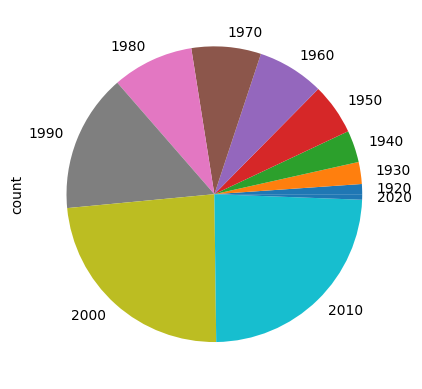

In [34]:
# Create a chart that shows the percentage of movies in each decade.
decade_counts.plot(kind='pie')

Text(0, 0.5, 'Number of Movies')

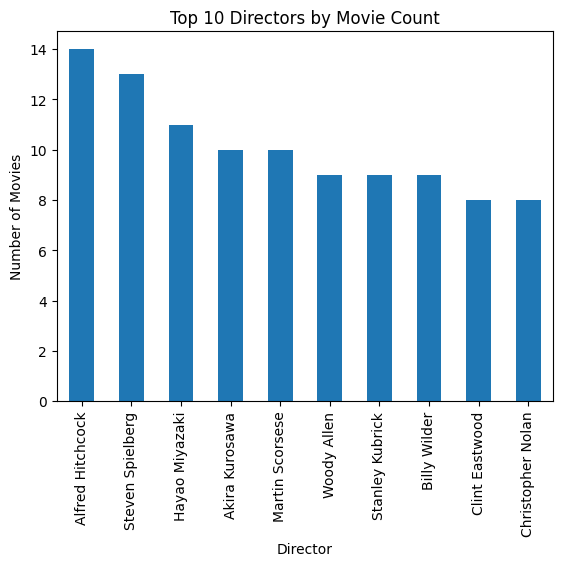

In [37]:
# Count movies by director.
# Show the top 10 directors by movie count in a bar chart.
Top_Directors_by_Movie_Count = imdb['Director'].value_counts().head(10)
Top_Directors_by_Movie_Count.plot(kind='bar')
plt.title("Top 10 Directors by Movie Count")
plt.xlabel("Director")
plt.ylabel("Number of Movies")

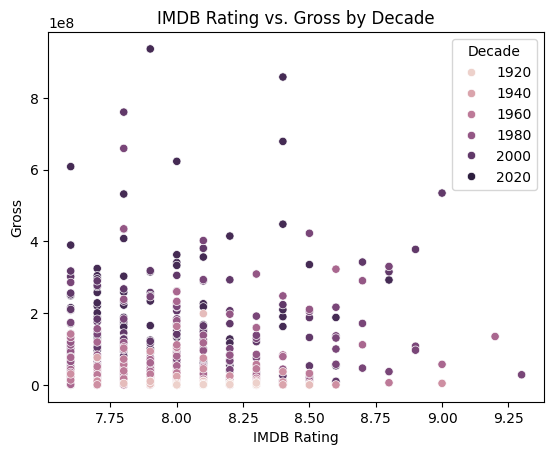

In [40]:
# Create a scatterplot of "IMDB_Rating" and "Gross".
# Use color to distinguish movies from different decades.
# Briefly interpret what the chart shows.
sns.scatterplot(
    data=imdb,
    x='IMDB_Rating',
    y='Gross',
    hue='Decade'
)

plt.title("IMDB Rating vs. Gross by Decade")
plt.xlabel("IMDB Rating")
plt.ylabel("Gross")

plt.legend(title='Decade')

plt.show()

# this chart shows that the spread of revenure by IMDB is relatively evenly distributed with some outliers.
# we do see larger gross with newer movies

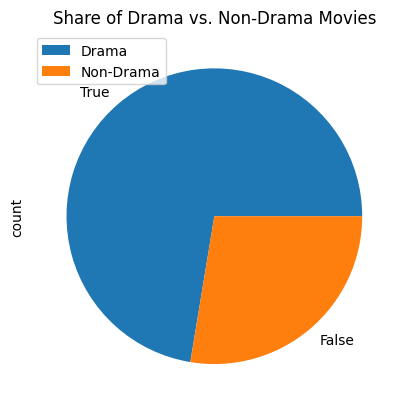

In [44]:
# Create a column named "Drama" that indicates whether a movie's genres include "Drama".
# Create a pie chart showing the share of drama vs. non-drama movies.
imdb['Drama'] = imdb['Genre'].str.contains('Drama')
imdb['Drama'].value_counts().plot(kind='pie')
plt.title("Share of Drama vs. Non-Drama Movies")
labels = ['Drama', 'Non-Drama']
plt.legend(labels)
plt.show()


Text(0, 0.5, 'Average Gross Revenue')

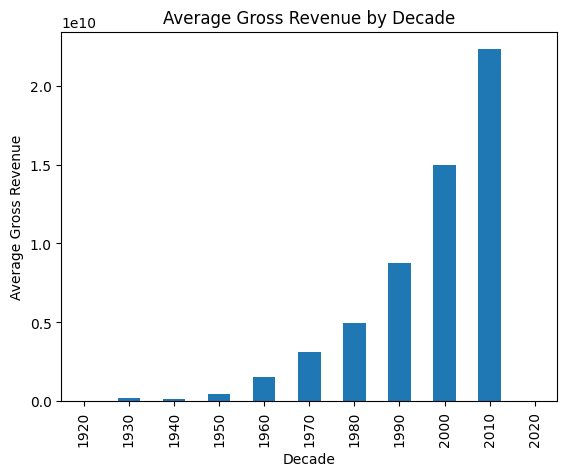

In [47]:
# Create a plot comparing gross revenue across decades.
imdb.groupby('Decade')['Gross'].sum().plot(kind='bar')
plt.title("Average Gross Revenue by Decade")
plt.xlabel("Decade")
plt.ylabel("Average Gross Revenue")

Text(0, 0.5, 'Number of Movies')

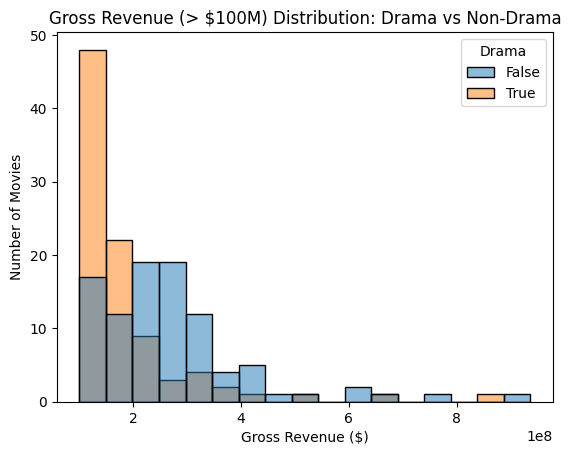

In [48]:
# For movies with gross over $100 million:
# Create a histogram of gross for drama vs. non-drama movies.
high_gross_movies = imdb[imdb['Gross'] > 100000000]
sns.histplot(
    data=high_gross_movies,
    x='Gross',
    hue='Drama',
)
plt.title("Gross Revenue (> $100M) Distribution: Drama vs Non-Drama")
plt.xlabel("Gross Revenue ($)")
plt.ylabel("Number of Movies")

Text(0, 0.5, 'Number of Movies')

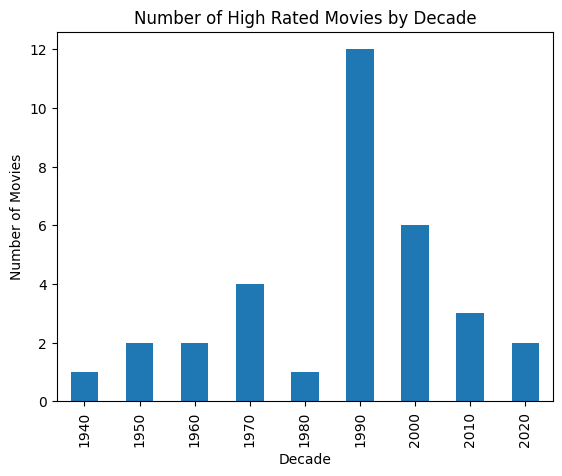

In [50]:
# Come up with two more questions about this dataset. Create one chart or figure for each.
# Question 1: Which decades have the most high rated movies
High_Rated_Movies = imdb[imdb['IMDB_Rating'] > 8.5]
High_Rated_Movies.groupby('Decade')['IMDB_Rating'].count().plot(kind='bar')
plt.title("Number of High Rated Movies by Decade")
plt.xlabel("Decade")
plt.ylabel("Number of Movies")

Text(0, 0.5, 'Average Rating')

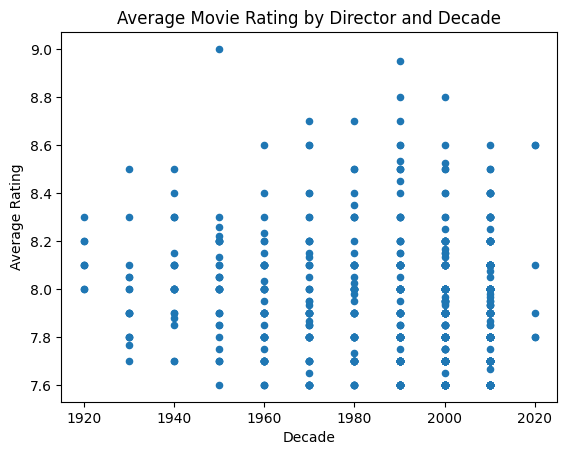

In [53]:
# Question 2: Which directors had best average movie rating by decade?
director_avg = imdb.groupby(['Director', 'Decade'])['IMDB_Rating'].mean().reset_index()
director_avg.plot(kind='scatter', x='Decade', y='IMDB_Rating')
plt.title("Average Movie Rating by Director and Decade")
plt.xlabel("Decade")
plt.ylabel("Average Rating")
